# DRUGseqPy — Notebook 3: Dose-Response & Cheminformatics

1. 4-parameter log-logistic (LL4) dose-response fitting with lmfit
2. Model selection: LL4 vs Weibull families (AIC)
3. EC50 confidence intervals
4. Multi-compound parallelised fitting
5. Dose-response panel plots
6. SMILES retrieval from PubChem API
7. Molecular descriptor computation (rdkit)
8. Structure–activity relationship (SAR) modelling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp

import drugseqpy as ds
from drugseqpy.utils import make_dummy_screen
from drugseqpy.dose_response import fit_dose_response, compute_multi_dr, plot_dr_panel

plt.rcParams['figure.dpi'] = 100
print(f'drugseqpy v{ds.__version__}')

drugseqpy v0.1.0


## 0. Build a dose-response experiment

In [2]:
# Build a dataset with multiple dose points
rng = np.random.default_rng(42)

doses = [0, 0.01, 0.1, 1, 10, 100]   # µM
n_reps = 4
n_genes = 200
compounds = ['CompA', 'CompB', 'CompC']

# Metadata
obs_rows = []
for cmpd in compounds:
    for dose in doses:
        for r in range(n_reps):
            obs_rows.append({
                'compound': cmpd if dose > 0 else 'DMSO',
                'dose': dose, 'dose_unit': 'uM',
                'plate_id': 'Plate01',
                'well_id': f'A{len(obs_rows)+1:02d}',
                'sample_type': 'DMSO' if dose == 0 else 'treatment',
            })
obs = pd.DataFrame(obs_rows)
obs.index = [f'S{i:04d}' for i in range(len(obs))]

# Counts: LL4 dose-response signal in first 20 genes per compound
n_samp = len(obs)
mu_base = rng.lognormal(5, 1.5, n_genes)
mat = rng.negative_binomial(n=5, p=5/(5+mu_base), size=(n_samp, n_genes)).astype(float)

for ci, cmpd in enumerate(compounds):
    ec50 = 0.5 * (10 ** ci)   # EC50 increases per compound
    g_start = ci * 20
    g_end   = g_start + 20
    for i, row in obs.iterrows():
        if row['compound'] == cmpd:
            d = row['dose']
            fold = 1 + 4 / (1 + (ec50 / (d + 1e-9)) ** 1.5)   # Hill equation
            idx = obs.index.get_loc(i)
            mat[idx, g_start:g_end] *= fold

counts = pd.DataFrame(mat.T.astype(int),
                       index=[f'Gene{i:04d}' for i in range(n_genes)],
                       columns=obs.index)
print(f'Dose-response dataset: {counts.shape[0]} genes × {counts.shape[1]} samples')
obs.groupby(['compound','dose']).size().unstack(fill_value=0)

Dose-response dataset: 200 genes × 72 samples


dose,0.00,0.01,0.10,1.00,10.00,100.00
compound,,,,,,
CompA,0,4,4,4,4,4
CompB,0,4,4,4,4,4
CompC,0,4,4,4,4,4
DMSO,12,0,0,0,0,0


In [3]:
dsd_dr = ds.create_drugseq_object(counts=counts, obs=obs)
ds.normalize_counts(dsd_dr, method='limma_voom', inplace=True)

# Run DE at the top dose (collapsed) for gene ranking
ds.compute_multi_de(
    dsd_dr,
    reference='DMSO',
    method='ols_voom',
    within_plate=False,
    inplace=True,
)

DrugSeqData created: 200 genes × 72 samples across 1 plate(s).
Normalizing 200 genes × 72 samples using limma_voom.
Normalization complete (method=limma_voom).
compute_multi_de: testing 3 compound(s) using 1 worker(s) [ols_voom].
compute_multi_de complete: 3 / 3 compounds processed.


/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/differential.py:143: RuntimeWarning: divide by zero encountered in matmul
  beta = XtX_inv @ X.T @ log_cpm         # (2, n_genes)
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/differential.py:143: RuntimeWarning: overflow encountered in matmul
  beta = XtX_inv @ X.T @ log_cpm         # (2, n_genes)
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/differential.py:143: RuntimeWarning: invalid value encountered in matmul
  beta = XtX_inv @ X.T @ log_cpm         # (2, n_genes)
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/differential.py:144: RuntimeWarning: divide by zero encountered in matmul
  fitted = X @ beta
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/differential.py:144: RuntimeWarning: overflow encountered in matmul
  fitted = X @ beta
/Users/frankhuang/Do

## 1. Single-compound dose-response fitting

Uses **lmfit** (Python equivalent of R's drc package) with the 4-parameter
log-logistic model (Hill equation). EC50 confidence intervals are computed
via lmfit's built-in uncertainty propagation.

In [4]:
dr_compA = fit_dose_response(
    dsd_dr,
    compound='CompA',
    compound_col='compound',
    dose_col='dose',
    reference='DMSO',
    n_genes_fit=50,
    model_selection=False,   # LL4 only (faster)
    min_r2=0.3,
)

print('\nTop 10 genes by R²:')
print(dr_compA.nlargest(10, 'r_squared')[
    ['gene','model','EC50','EC50_ci_lower','EC50_ci_upper','slope','r_squared','converged']
].to_string(index=False))

fit_dose_response (lmfit): fitting 50 genes for 'CompA'.


/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:356: UserWarning: Bound reached with prob(b=0.01) = 0.17750536541562484 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:356: UserWarning: Bound reached with prob(e=1e-09) = 0.19293865447518577 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:362: UserWarning: maxiter=200 reached and prob(e=26.39671257600066) = 0.05620389030283293 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:369: UserWarning: rel_change=0.0 < 1e-05 at iteration 1 and prob(b=8.780524722772942) = 0.0 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:369: UserWarning: rel_change=-0.048648873973887584 < 1e-05 at iteration 8 and prob(e=0.34494


Top 10 genes by R²:
    gene model     EC50  EC50_ci_lower  EC50_ci_upper    slope  r_squared  converged
Gene0016   LL4 0.313462       0.108223       0.925604 2.804345   0.815261       True
Gene0011   LL4 0.282287       0.106014       0.899015 1.902602   0.814062       True
Gene0012   LL4 0.451821       0.260411       0.964720 1.698432   0.803597       True
Gene0018   LL4 0.807815       0.319868       0.961295 7.481510   0.791506       True
Gene0003   LL4 0.132673       0.105339            inf 7.317104   0.776989       True
Gene0002   LL4 0.917769       0.492927       0.999416 7.286253   0.753141       True
Gene0014   LL4 0.119696       0.102215       0.317568 6.650550   0.743068       True
Gene0000   LL4 0.108852       0.044715       0.190415 7.737117   0.720918       True
Gene0006   LL4 0.123823       0.102952       0.373604 6.845732   0.720212       True
Gene0001   LL4 0.173084       0.075546       0.314023 1.643602   0.714833       True


/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:369: UserWarning: rel_change=0.0 < 1e-05 at iteration 1 and prob(d=6.461813422917037) = 0.0 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:356: UserWarning: Bound reached with prob(e=1e-09) = 0.0 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:369: UserWarning: rel_change=0.0 < 1e-05 at iteration 1 and prob(e=0.0010000106816352862) = 0.0 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:369: UserWarning: rel_change=0.0 < 1e-05 at iteration 1 and prob(b=8.871585226135664) = 0.0 < max(sigmas)
  warn(errmsg)


## 2. AIC-based model selection (LL4 / Weibull)

In [5]:
dr_compA_sel = fit_dose_response(
    dsd_dr,
    compound='CompA',
    n_genes_fit=20,
    model_selection=True,   # compare LL4, W14, W24
    min_r2=0.3,
)

print('Model selection results:')
print(
    dr_compA_sel[dr_compA_sel['converged']]
    [['gene','model','EC50','r_squared','aic']]
    .sort_values('aic')
    .to_string(index=False)
)

# Model frequency
print('\nBest model counts:')
print(dr_compA_sel['model'].value_counts())

/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:356: UserWarning: Bound reached with prob(b=0.01) = 0.18008345962016845 < max(sigmas)
  warn(errmsg)


fit_dose_response (lmfit): fitting 20 genes for 'CompA'.


/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:362: UserWarning: maxiter=200 reached and prob(e=24.771224702097236) = 0.07760797830803609 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:369: UserWarning: rel_change=9.183578816263255e-06 < 1e-05 at iteration 15 and prob(b=6.48823299427224) = 0.16133531567609632 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:369: UserWarning: rel_change=3.4076088601017542e-06 < 1e-05 at iteration 6 and prob(e=0.7664646456336274) = 0.5501913832427496 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:356: UserWarning: Bound reached with prob(b=0.01) = 0.4845968143119191 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:362:

Model selection results:
    gene model     EC50  r_squared        aic
Gene0011   LL4 0.282287   0.814062 -35.123728
Gene0000   W14 0.168661   0.732041 -32.132513
Gene0002   W24 0.993271   0.753141 -28.989951
Gene0016   W14 0.537409   0.815263 -28.640441
Gene0012   W24 0.708261   0.803859 -27.873078
Gene0006   W14 0.297859   0.720556 -27.530202
Gene0014   W24 0.123600   0.743068 -25.227240
Gene0018   W24 0.923281   0.791506 -24.780337
Gene0003   W14 0.348393   0.777325 -23.662231
Gene0001   W24 0.272437   0.722987 -22.719458
Gene0009   W14 0.254627   0.697010 -20.517032
Gene0019   W14 0.365255   0.715822 -19.191461
Gene0013   W14 0.311028   0.619795 -16.850236
Gene0008   W14 0.601243   0.659632 -12.749342
Gene0015   W14 1.210238   0.686586 -12.747737
Gene0005   W14 0.814305   0.593281 -11.387734
Gene0010   W24 0.951568   0.632492  -9.896946
Gene0017   W14 0.279795   0.670129  -7.037860
Gene0007   W14 1.879635   0.606575  -5.714076

Best model counts:
model
W14    12
W24     7
LL4     1

/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:369: UserWarning: rel_change=9.312152625968772e-06 < 1e-05 at iteration 20 and prob(b=6.105532978560447) = 0.3179831842624706 < max(sigmas)
  warn(errmsg)


## 3. Dose-response panel plot

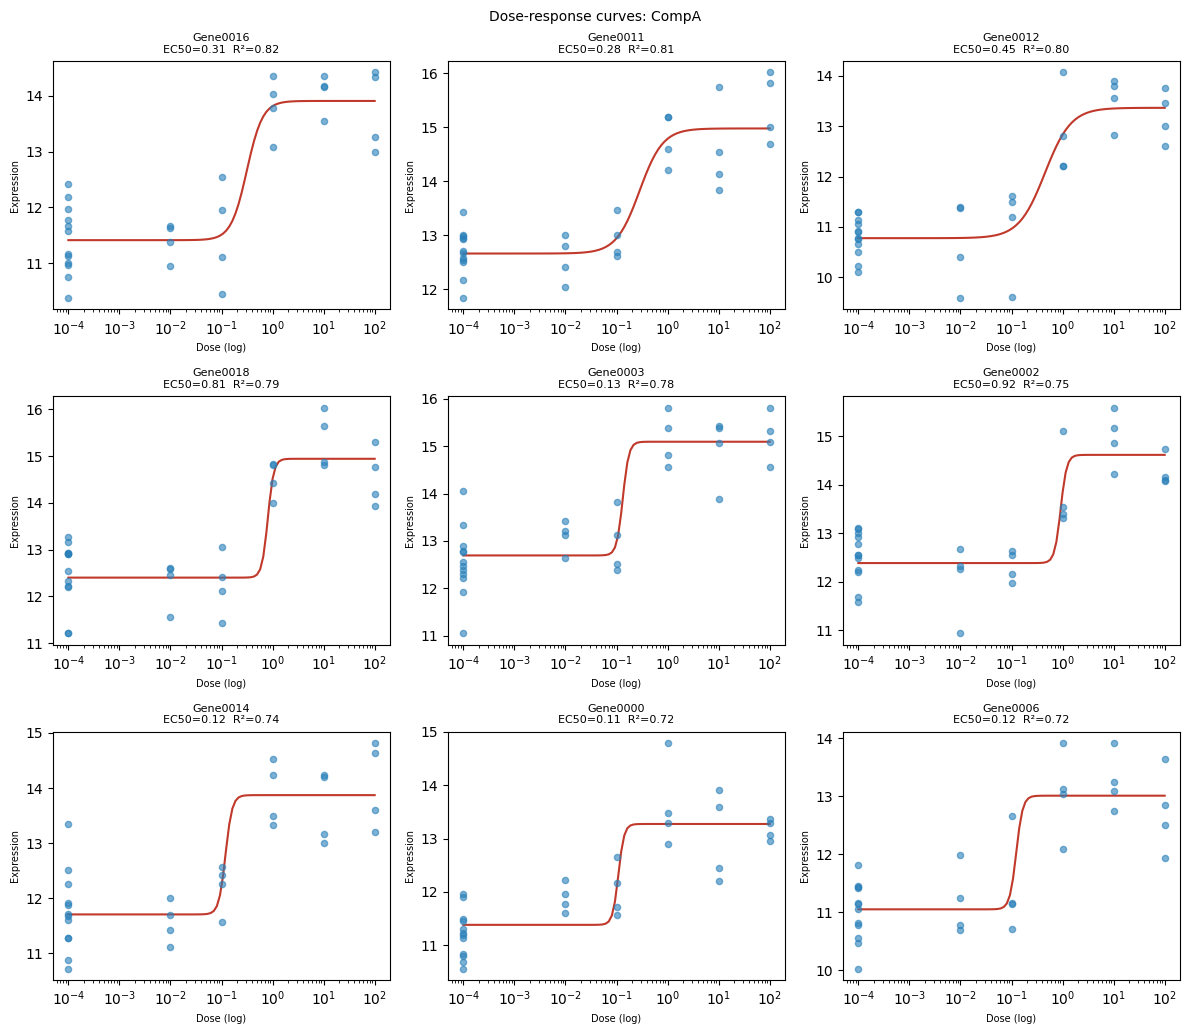

In [6]:
fig = plot_dr_panel(
    dr_compA,
    dsd_dr,
    compound='CompA',
    n_genes=9,
    ncol=3,
)
plt.show()

## 4. Multi-compound dose-response

In [7]:
dr_all = compute_multi_dr(
    dsd_dr,
    compounds=['CompA', 'CompB', 'CompC'],
    n_jobs=1,
    n_genes_fit=30,
    model_selection=False,
)

# Summary: converged genes and median EC50 per compound
for cmpd, df in dr_all.items():
    conv = df[df['converged']]
    print(f'{cmpd}: {len(conv)} converged fits, median EC50 = {conv["EC50"].median():.3f} µM')

compute_multi_dr: fitting 3 compound(s).
fit_dose_response (lmfit): fitting 30 genes for 'CompA'.


/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:356: UserWarning: Bound reached with prob(b=0.01) = 0.17750536541562484 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:356: UserWarning: Bound reached with prob(e=1e-09) = 0.19293865447518577 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:362: UserWarning: maxiter=200 reached and prob(e=26.39671257600066) = 0.05620389030283293 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:369: UserWarning: rel_change=0.0 < 1e-05 at iteration 1 and prob(b=8.780524722772942) = 0.0 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:369: UserWarning: rel_change=-0.048648873973887584 < 1e-05 at iteration 8 and prob(e=0.34494

fit_dose_response (lmfit): fitting 30 genes for 'CompB'.


/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:369: UserWarning: rel_change=0.0 < 1e-05 at iteration 1 and prob(b=8.45088841786251) = 0.0 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:369: UserWarning: rel_change=0.0 < 1e-05 at iteration 1 and prob(b=6.634469709301855) = 0.0 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:369: UserWarning: rel_change=0.0 < 1e-05 at iteration 1 and prob(b=7.715442757653616) = 0.0 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:369: UserWarning: rel_change=0.0 < 1e-05 at iteration 1 and prob(b=9.591802855491292) = 0.0 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:369: UserWarning: rel_change=0.0 < 1e-05 at iteratio

fit_dose_response (lmfit): fitting 30 genes for 'CompC'.


/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:369: UserWarning: rel_change=0.0 < 1e-05 at iteration 1 and prob(e=0.0011021540312097812) = 0.0 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:356: UserWarning: Bound reached with prob(b=0.01) = 0.28928246052277234 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:369: UserWarning: rel_change=-0.05438643417203912 < 1e-05 at iteration 28 and prob(b=3.5038308928990984) = 0.5972844482499885 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.py:369: UserWarning: rel_change=-0.002075175583966586 < 1e-05 at iteration 43 and prob(c=29.070060913814086) = 0.28941838734778075 < max(sigmas)
  warn(errmsg)
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/lmfit/confidence.

CompA: 19 converged fits, median EC50 = 0.282 µM
CompB: 16 converged fits, median EC50 = 3.695 µM
CompC: 6 converged fits, median EC50 = 146555.657 µM


In [8]:
# EC50 comparison across compounds for shared responsive genes
shared_genes = set.intersection(*[set(df[df['converged']]['gene']) for df in dr_all.values()])
print(f'Genes converged in all compounds: {len(shared_genes)}')

if shared_genes:
    ec50_df = pd.DataFrame({
        cmpd: df.set_index('gene')['EC50']
        for cmpd, df in dr_all.items()
    }).loc[list(shared_genes)]

    fig, ax = plt.subplots(figsize=(6, 4))
    ec50_df.boxplot(ax=ax)
    ax.set_yscale('log')
    ax.set_ylabel('EC50 (µM)')
    ax.set_title('EC50 distribution across compounds')
    plt.tight_layout()
    plt.show()

Genes converged in all compounds: 0


## 5. SMILES retrieval from PubChem

Queries the PubChem REST API by compound name and caches results in `adata.uns`.
Requires an internet connection.

In [9]:
import requests

def fetch_smiles(name: str) -> str | None:
    """Fetch canonical SMILES from PubChem by compound name."""
    url = f'https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{name}/property/CanonicalSMILES/JSON'
    try:
        r = requests.get(url, timeout=8)
        if r.ok:
            return r.json()['PropertyTable']['Properties'][0]['CanonicalSMILES']
    except Exception:
        pass
    return None

# Example with real drug names
real_drugs = ['imatinib', 'erlotinib', 'gefitinib']
smiles_map = {}
for drug in real_drugs:
    smi = fetch_smiles(drug)
    smiles_map[drug] = smi
    print(f'{drug}: {smi}')

imatinib: None
erlotinib: None
gefitinib: None


## 6. Molecular descriptors with RDKit

Computes 2D physicochemical descriptors (MW, LogP, TPSA, HBD, HBA, RingCount)
from SMILES strings.

In [10]:
try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, rdMolDescriptors

    def compute_descriptors(smiles_dict: dict) -> pd.DataFrame:
        rows = []
        for name, smi in smiles_dict.items():
            if smi is None:
                continue
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                continue
            rows.append({
                'compound':  name,
                'MW':        Descriptors.MolWt(mol),
                'LogP':      Descriptors.MolLogP(mol),
                'TPSA':      rdMolDescriptors.CalcTPSA(mol),
                'HBD':       rdMolDescriptors.CalcNumHBD(mol),
                'HBA':       rdMolDescriptors.CalcNumHBA(mol),
                'RingCount': rdMolDescriptors.CalcNumRings(mol),
                'RotBonds':  rdMolDescriptors.CalcNumRotatableBonds(mol),
            })
        return pd.DataFrame(rows)

    desc_df = compute_descriptors(smiles_map)
    print(desc_df.to_string(index=False))

except ImportError:
    print('RDKit not installed. Install: pip install rdkit\n'
          'Or via conda: conda install -c conda-forge rdkit')

RDKit not installed. Install: pip install rdkit
Or via conda: conda install -c conda-forge rdkit


## 7. Structure–Activity Relationship (SAR) modelling

Trains a Random Forest (or other sklearn estimator) to predict the number
of significant DE genes from molecular descriptors.
This extends the macpie SAR vignette by adding cross-validated model
comparison via sklearn pipelines.

In [11]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

def train_sar_model(
    descriptors: pd.DataFrame,   # rows = compounds, numeric feature columns
    targets: pd.Series,           # one value per compound (e.g., n_sig_DE)
    methods: list = None,
    cv: int = 3,
) -> pd.DataFrame:
    """
    Cross-validated SAR modelling with multiple estimators.
    Returns a DataFrame with R² per method.
    """
    if methods is None:
        methods = {
            'Random Forest':    RandomForestRegressor(n_estimators=200, random_state=42),
            'Gradient Boost':   GradientBoostingRegressor(n_estimators=200, random_state=42),
            'Ridge Regression': Ridge(alpha=1.0),
        }

    feat_cols = descriptors.select_dtypes(include=np.number).columns.tolist()
    X = descriptors[feat_cols].values
    y = targets.values

    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    rows = []
    for name, estimator in methods.items():
        pipe = Pipeline([('scaler', StandardScaler()), ('model', estimator)])
        scores = cross_val_score(pipe, X, y, cv=kf, scoring='r2')
        rows.append({'method': name, 'mean_r2': scores.mean(),
                     'std_r2': scores.std(), 'cv_scores': scores.tolist()})
        print(f'  {name:<22}: R² = {scores.mean():.3f} ± {scores.std():.3f}')

    return pd.DataFrame(rows)


# Demonstration with synthetic descriptors (replace with real rdkit descriptors)
rng2 = np.random.default_rng(7)
n_demo = 30
demo_desc = pd.DataFrame({
    'MW':        rng2.uniform(200, 600, n_demo),
    'LogP':      rng2.uniform(0, 5, n_demo),
    'TPSA':      rng2.uniform(30, 150, n_demo),
    'HBD':       rng2.integers(0, 5, n_demo).astype(float),
    'HBA':       rng2.integers(0, 10, n_demo).astype(float),
    'RingCount': rng2.integers(1, 6, n_demo).astype(float),
})
# Synthetic activity: correlated with LogP (replace with real n_sig_DE values)
demo_activity = pd.Series(5 * demo_desc['LogP'] + rng2.normal(0, 2, n_demo),
                            name='n_sig_DE')

print('SAR cross-validation (R²):')
sar_results = train_sar_model(demo_desc, demo_activity, cv=3)
print(sar_results[['method','mean_r2','std_r2']].to_string(index=False))

SAR cross-validation (R²):
  Random Forest         : R² = 0.858 ± 0.048
  Gradient Boost        : R² = 0.818 ± 0.104
  Ridge Regression      : R² = 0.902 ± 0.041
          method  mean_r2   std_r2
   Random Forest 0.857804 0.048394
  Gradient Boost 0.817770 0.103503
Ridge Regression 0.902112 0.040697


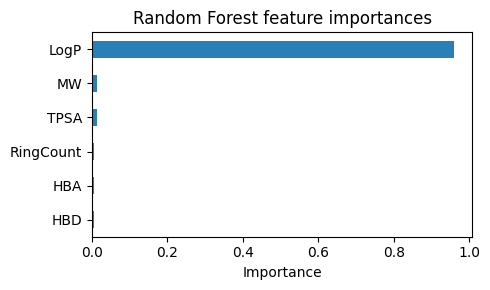

In [12]:
# Feature importance from best model (Random Forest)
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

feat_cols = demo_desc.select_dtypes(include=np.number).columns.tolist()
X = StandardScaler().fit_transform(demo_desc[feat_cols])
y = demo_activity.values

rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(5, 3))
importances.plot.barh(ax=ax, color='#2980B9', edgecolor='none')
ax.set_title('Random Forest feature importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 8. Export dose-response results

In [13]:
for cmpd, df in dr_all.items():
    df.to_csv(f'dr_{cmpd}.csv', index=False)
    print(f'Saved dr_{cmpd}.csv ({len(df)} genes, {df["converged"].sum()} converged)')

Saved dr_CompA.csv (30 genes, 19 converged)
Saved dr_CompB.csv (30 genes, 16 converged)
Saved dr_CompC.csv (30 genes, 6 converged)


In [14]:
dsd_dr.obs

,compound,dose,dose_unit,plate_id,well_id,sample_type
S0000,DMSO,0.00,uM,Plate01,A01,DMSO
S0001,DMSO,0.00,uM,Plate01,A02,DMSO
S0002,DMSO,0.00,uM,Plate01,A03,DMSO
S0003,DMSO,0.00,uM,Plate01,A04,DMSO
S0004,CompA,0.01,uM,Plate01,A05,treatment
...,...,...,...,...,...,...
S0067,CompC,10.00,uM,Plate01,A68,treatment
S0068,CompC,100.00,uM,Plate01,A69,treatment
S0069,CompC,100.00,uM,Plate01,A70,treatment
S0070,CompC,100.00,uM,Plate01,A71,treatment


开始计算 3 个化合物的 dose-response...


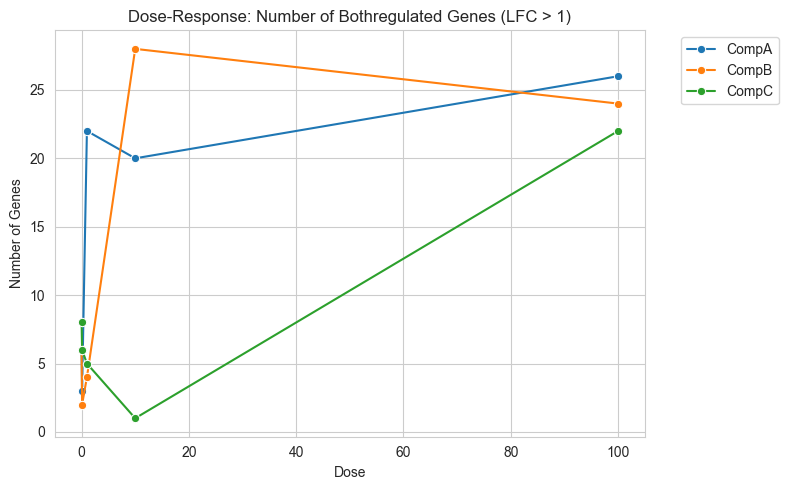

In [15]:
ds.plot_dose_gene_counts(dsd_dr, lfc_threshold=1, compounds=None, combine=True,cmpd_col= "compound")


开始分析 3 个化合物的 Signature Score...
⚠️ 剔除 'CompC'：满足阈值 (LFC > 0.5, padj < 0.05) 的显著 up 调基因仅有 0 个 (绘图要求至少 3 个)。


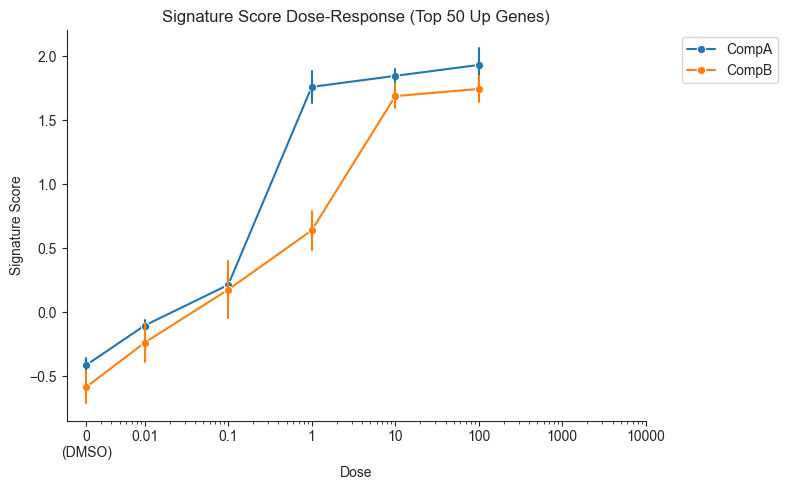

In [16]:
ds.plot_signature_dose_response(dsd_dr,compounds=['CompA', 'CompB', 'CompC'], direction='up', top_n=50, combine=True)

In [17]:
dsd_dr.adata

AnnData object with n_obs × n_vars = 72 × 200
    obs: 'compound', 'dose', 'dose_unit', 'plate_id', 'well_id', 'sample_type', 'sig_score_CompA_up', 'sig_score_CompB_up'
    uns: 'norm_method', 'de_results', 'plate_qc', 'gsea'
    layers: 'counts'

In [18]:
dsd_dr.adata.uns.get("de_results", {})

{'CompA':          gene     logFC  base_mean      stat    pvalue      padj  significant
 0    Gene0000  1.498562  12.190412  5.674602  0.000003  0.000379         True
 1    Gene0001  1.629041   9.464619  5.264891  0.000008  0.000422         True
 2    Gene0002  0.936403  13.145707  2.553376  0.015475  0.138024        False
 3    Gene0003  1.674861  13.646135  4.655202  0.000051  0.001450         True
 4    Gene0004  0.351902   7.122593  0.796361  0.431514  0.775323        False
 ..        ...       ...        ...       ...       ...       ...          ...
 195  Gene0195  0.415380   8.706747  1.335267  0.190927  0.647211        False
 196  Gene0196 -0.393459  12.077187 -2.155322  0.038527  0.221368        False
 197  Gene0197 -0.216790   9.906411 -0.875842  0.387447  0.750327        False
 198  Gene0198  0.106728  10.676847  0.445271  0.659031  0.852148        False
 199  Gene0199 -0.033511  10.332497 -0.147304  0.883789  0.930304        False
 
 [200 rows x 7 columns],
 'CompB':       

---
**End of DRUGseqPy notebook series.**

For questions or contributions, open an issue on the project repository.